In [8]:
import dataset, features, modeling, plots
import pandas as pd

# Tworzenie modeli

Przy doborze portfeli inwestycyjnych jednym z kluczowych parametrów jest **liczba spółek wchodzących** w ich skład. Liczba ta może być zmienna — co często występuje w portfelach aktywnie zarządzanych — lub stała, co jest typowe dla portfeli dobieranych automatycznie według określonych reguł.

Za optymalną równowagę pomiędzy dywersyfikacją a koncentracją portfela uznaje się zazwyczaj od 10 do 20 spółek. Zbyt duża liczba walorów może prowadzić do osiągania stóp zwrotu zbliżonych do indeksu rynkowego, a często nawet niższych. Z kolei nadmierna specjalizacja powoduje, że wyniki pojedynczych spółek mają zbyt duży wpływ na wartość całego portfela, zwiększając jego ryzyko.

W dalszej części pracy, przy analizie poszczególnych strategii, przyjęto środkową wartość tego przedziału, czyli portfel składający się z `N` = 15 spółek.

Kolejnym analizowanym parametrem jest **częstotliwość doboru** portfela, rozpatrywana w wariantach miesięcznym, kwartalnym oraz rocznym. Każda z tych częstotliwości wiąże się z inną równowagą pomiędzy szybkością reakcji na zmiany rynkowe a kosztami oraz stabilnością portfela. W ramach pracy przeprowadzone zostaną testy dla każdego z rozważanych wariantów.

Należy zaznaczyć również, że rzeczywiste stopy zwrotu byłyby niższe, szczególnie dla comiesięcznego doboru ze względu na koszty zmiany składu portfela.

Ekstremalne dzienne zwroty są odrzucane dla obu strategii, gdyż są one spowodowane błędami w zbiorze danych.

Loaded merged data with 8 price fields


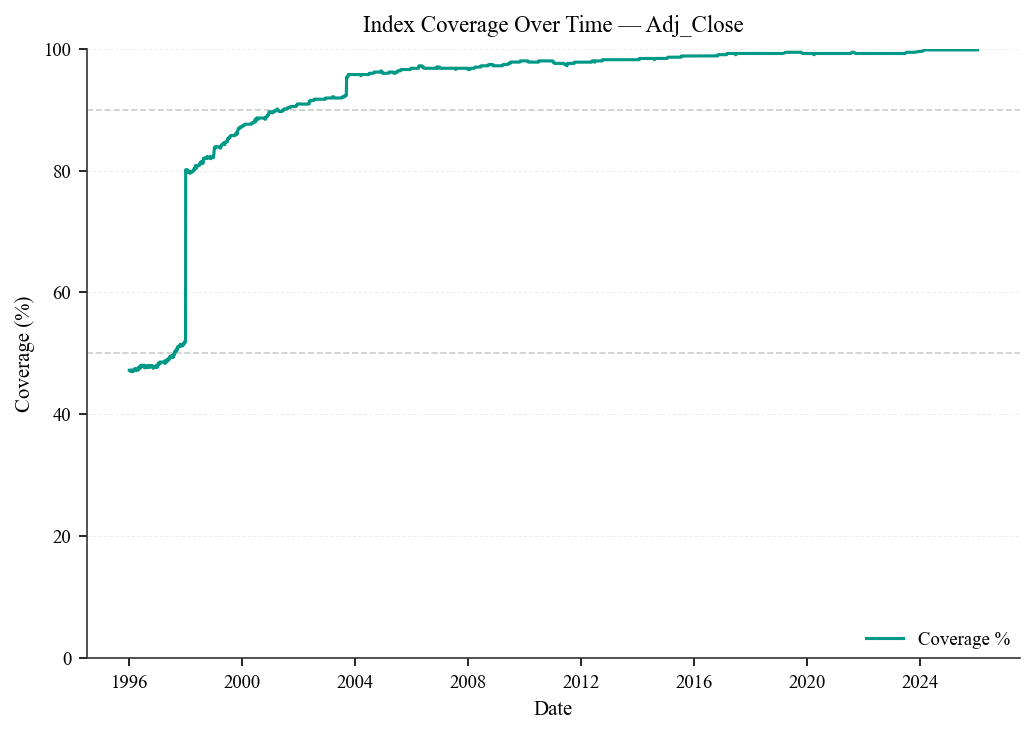

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 1997-12-29
  missing from 2008-11-18 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2003-09-08
  missing from 2005-05-13 to 2005-06-06
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-03-22
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- AM:
  missing from 1996-01-02 to 1997-12-29
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-29
- ANRZQ:
  missing from 2011-06-02

In [9]:
sp500_components: pd.DataFrame = dataset.SP500.load_historical()
merged_data: dict[str, pd.DataFrame] = features.load_merged_data()
coverage: pd.DataFrame = plots.coverage_over_time(
    price_data=merged_data,
    components=sp500_components,
    save_figures=False
)
missing_tickers: pd.DataFrame = pd.read_csv("../data/processed/missing_ticker.csv", index_col=0, parse_dates=True)
benchmark_df: pd.DataFrame = pd.read_csv("../data/processed/benchmark_2026-04-19.csv", index_col=0, parse_dates=True)
N = 15

## Model losowy

Najprostszą strategią, którą można przetestować jest model losowy, który losowo daną liczbę spółek cyklicznie.

In [10]:
modeling.select_random(sp500_components, n=N, coverage=coverage, date="2001-01-01")

{'tickers': ['NWL',
  'BCR',
  'ADI',
  'RF',
  'DG',
  'CSX',
  'CNXT',
  'BMET',
  'RDC',
  'BAX',
  'PD',
  'UNM',
  'MBI',
  'AVY',
  'MTG'],
 'difference': 2}

In [11]:
random_M = modeling.select_random_periodic(
    components=sp500_components,
    n=N,
    start_date="2001-01-01",
    frequency="monthly",
    coverage=coverage
)
plots.summarize_df(random_M)
random_Q = modeling.select_random_periodic(
    components=sp500_components,
    n=N, 
    start_date="2001-01-01",
    frequency="quarterly",
    coverage=coverage
)
plots.summarize_df(random_Q)
random_Y = modeling.select_random_periodic(
    components=sp500_components,
    n=N,
    start_date="2001-01-01",
    frequency="yearly",
    coverage=coverage
)
plots.summarize_df(random_Y)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        301 non-null    datetime64[us]
 1   tickers     301 non-null    object        
 2   difference  301 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 7.2+ KB
None


,date,difference
count,301,301.00000000
mean,2013-07-01 13:28:30.299003,0.21926910
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-01 00:00:00,0.00000000
50%,2013-07-01 00:00:00,0.00000000
75%,2019-10-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.45287319


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        101 non-null    datetime64[us]
 1   tickers     101 non-null    object        
 2   difference  101 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 2.5+ KB
None


,date,difference
count,101,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-01 00:00:00,0.00000000
50%,2013-07-01 00:00:00,0.00000000
75%,2019-10-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.43826842


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        26 non-null     datetime64[us]
 1   tickers     26 non-null     object        
 2   difference  26 non-null     int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 756.0+ bytes
None


,date,difference
count,26,26.00000000
mean,2013-07-02 06:27:41.538461,0.26923077
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-02 06:00:00,0.00000000
50%,2013-07-02 12:00:00,0.00000000
75%,2019-10-01 18:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.53349357


,date,tickers,difference
0,2001-01-01,"[NWL, BCR, ADI, RF, DG, CSX, CNXT, BMET, RDC, ...",2
1,2002-01-01,"[HNZ, ADSK, ADP, AWE, CNP, CPNLQ, KMI, MTG, AD...",1
24,2025-01-01,"[CME, KR, HRL, BX, HAL, CINF, DOW, IBM, DAY, T...",0
25,2026-01-01,"[TKO, LIN, AZO, AMCR, NKE, LDOS, T, ADBE, XOM,...",0


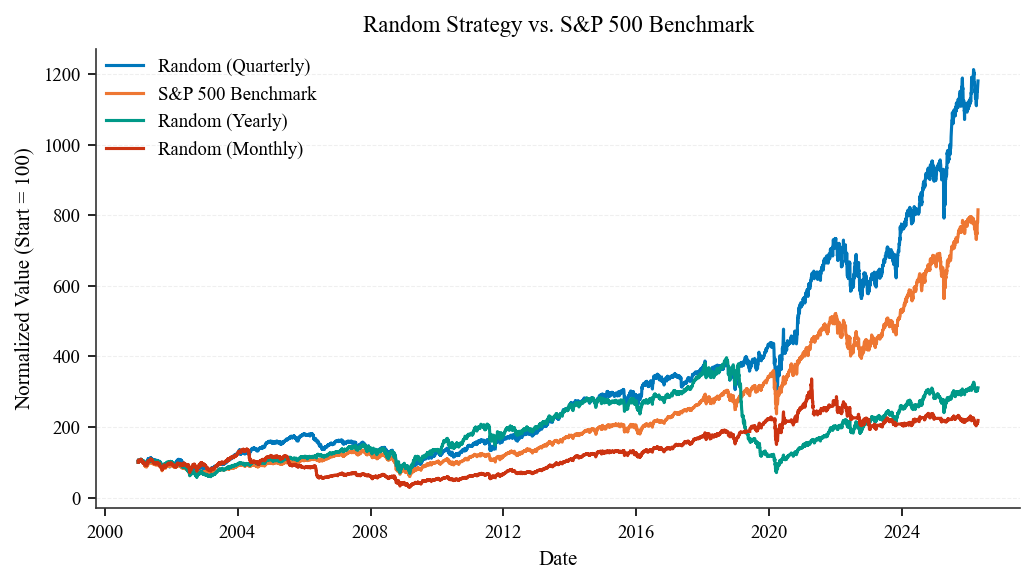

,Random (Quarterly),S&P 500 Benchmark,Random (Yearly),Random (Monthly)
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,106.38738043,105.02137510,106.38738043,106.38738043
2001-01-04,104.20752139,103.91462970,104.20752139,104.20752139
2001-01-05,100.81902866,101.18692175,100.81902866,100.81902866
2001-01-08,101.52241908,101.01253978,101.52241908,101.52241908
...,...,...,...,...
2026-04-13,1162.40522508,778.63843905,306.93082166,212.57559742
2026-04-14,1170.84993926,793.51742181,306.86247115,214.54477271
2026-04-15,1169.29568738,798.58685969,308.11749130,215.03786897


In [12]:
portfolio_random_M = modeling.backtest_portfolio(
    selected_companies=random_M, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_random_Q = modeling.backtest_portfolio(
    selected_companies=random_Q, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_random_Y = modeling.backtest_portfolio(
    selected_companies=random_Y, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Random (Monthly)": portfolio_random_M,
        "Random (Quarterly)": portfolio_random_Q,
        "Random (Yearly)": portfolio_random_Y,
        "S&P 500 Benchmark": benchmark_df
    },
    title="Random Strategy vs. S&P 500 Benchmark",
    filename="24-random-strategy.png",
)

Można zauważyć, że taki model losowy dla częstszego doboru radzi sobie wyraźnie gorzej dla doboru miesięcznego i rocznego od benchmarku. Dla doboru kwartalnego - wyraźnie lepiej, co budzi wątpliwości co do jakości zbioru danych bądź implementacji. Dlatego jego wynik należy traktować ostrożnie.

## Model Monte Carlo

W przypadku metody Monte Carlo dochodzi kolejny czynnik - **okno wstecz**, które przyjąłem za rok, a więc w przybliżeniu 252 dni handlowych.

W poniższej strategii Monte Carlo to losowanie wielu portfeli, a nie symulacja ścieżek cen dla pojedynczych spółek. Dla każdej daty rebalansu wybiera się aktywne spółki z indeksu i zostawia te z wystarczającą liczbą obserwacji w oknie wstecz.
Dla każdej spółki liczę średni dzienny zwrot i zmienność, po czym losuje się określoną liczbę portfeli (przyjęto: 500) po `N` spółek. Wybrany portfel to ten o najwyższym wskaźniku `score = mean/vol` (średni zwrot podzielony przez zmienność).

In [13]:
mc_M = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="monthly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(mc_M)
mc_Q = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="quarterly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(mc_Q)
mc_Y = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="yearly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
)
plots.summarize_df(mc_Y)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        301 non-null    datetime64[us]
 1   tickers     301 non-null    object        
 2   difference  301 non-null    int64         
 3   score       301 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 9.5+ KB
None


,date,difference,score
count,301,301.00000000,301.00000000
mean,2013-07-01 13:28:30.299003,0.21926910,0.07339874
min,2001-01-01 00:00:00,0.00000000,-0.02373405
25%,2007-04-01 00:00:00,0.00000000,0.05073321
50%,2013-07-01 00:00:00,0.00000000,0.07710730
75%,2019-10-01 00:00:00,0.00000000,0.09428594
max,2026-01-01 00:00:00,2.00000000,0.13608661
std,NaN,0.45287319,0.03026973


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        101 non-null    datetime64[us]
 1   tickers     101 non-null    object        
 2   difference  101 non-null    int64         
 3   score       101 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 3.3+ KB
None


,date,difference,score
count,101,101.00000000,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178,0.07324025
min,2001-01-01 00:00:00,0.00000000,-0.00241688
25%,2007-04-01 00:00:00,0.00000000,0.05460288
50%,2013-07-01 00:00:00,0.00000000,0.07922169
75%,2019-10-01 00:00:00,0.00000000,0.09351356
max,2026-01-01 00:00:00,2.00000000,0.12735902
std,NaN,0.43826842,0.03132324


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        26 non-null     datetime64[us]
 1   tickers     26 non-null     object        
 2   difference  26 non-null     int64         
 3   score       26 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 964.0+ bytes
None


,date,difference,score
count,26,26.00000000,26.00000000
mean,2013-07-02 06:27:41.538461,0.26923077,0.07468966
min,2001-01-01 00:00:00,0.00000000,-0.00346334
25%,2007-04-02 06:00:00,0.00000000,0.05759971
50%,2013-07-02 12:00:00,0.00000000,0.08145679
75%,2019-10-01 18:00:00,0.00000000,0.09623232
max,2026-01-01 00:00:00,2.00000000,0.11749841
std,NaN,0.53349357,0.03132787


,date,tickers,difference,score
0,2001-01-01,"[WEN, CAH, NBR, COP, ED, SVU, PHM, AZO, STJ, A...",2,0.07556572
1,2002-01-01,"[ODP, CCL, HI, TGT, BAX, DLX, CCTYQ, MAT, BBT,...",1,0.05700568
24,2025-01-01,"[PSX, GLW, CHD, BKR, PEG, MA, PLTR, UNP, SYF, ...",0,0.10192172
25,2026-01-01,"[IBM, FCX, NEM, JBHT, KLAC, ANET, CPB, WRB, FF...",0,0.07338123


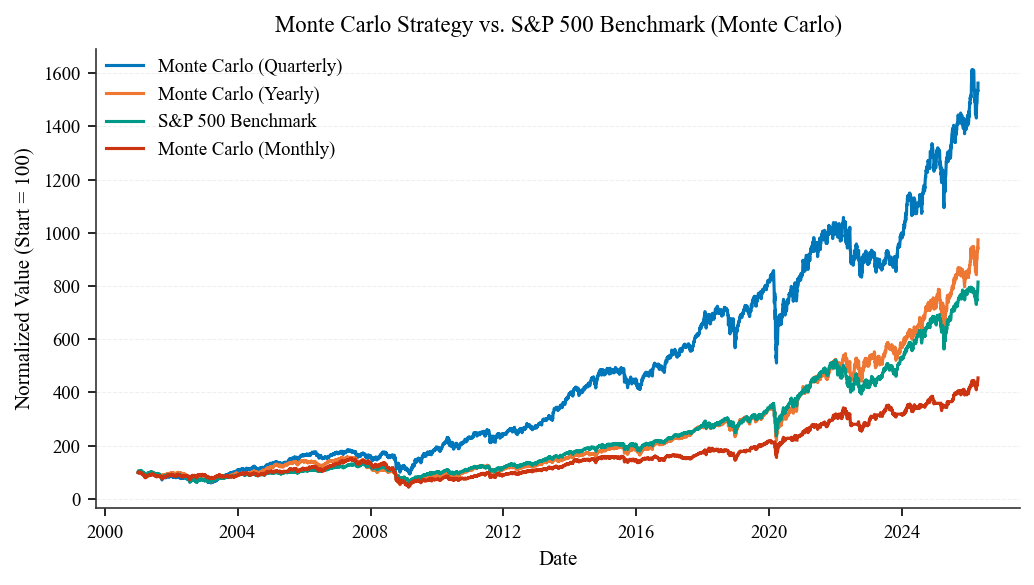

,Monte Carlo (Quarterly),Monte Carlo (Yearly),S&P 500 Benchmark,Monte Carlo (Monthly)
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,102.08751784,102.08751784,105.02137510,102.08751784
2001-01-04,99.42945510,99.42945510,103.91462970,99.42945510
2001-01-05,97.58734245,97.58734245,101.18692175,97.58734245
2001-01-08,97.66898716,97.66898716,101.01253978,97.66898716
...,...,...,...,...
2026-04-13,1533.40845777,935.15891030,778.63843905,440.46941676
2026-04-14,1536.70229486,945.26612192,793.51742181,445.76711606
2026-04-15,1531.47897929,939.80241714,798.58685969,446.61058460


In [14]:
portfolio_mc_M = modeling.backtest_portfolio(
    selected_companies=mc_M,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_mc_Q = modeling.backtest_portfolio(
    selected_companies=mc_Q,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_mc_Y = modeling.backtest_portfolio(
    selected_companies=mc_Y,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Monte Carlo (Monthly)": portfolio_mc_M,
        "Monte Carlo (Quarterly)": portfolio_mc_Q,
        "Monte Carlo (Yearly)": portfolio_mc_Y,
        "S&P 500 Benchmark": benchmark_df
    },
    title="Monte Carlo Strategy vs. S&P 500 Benchmark (Monte Carlo)",
    filename="25-mc-strategy.png",
)

W przypadku strategii opartej na Monte Carlo również to dobór kwartalny daje najlepsze wyniki. Wynik zbliżony, ale lekko powyżej benchmarku osiąga dobór miesięczny, co jest dosyć zrozumiałe - to dosyć krótki okres dla inwestowania w akcje.

Ponownie - wyniki z tej strategii również należy brać z ostrożnością.